# Projeto Final - Aprendizado de Máquina

## 1. Identificação e descrição do problema
* **Título:** Predição de Doenças Cardíacas utilizando Aprendizado de Máquina
* **Integrantes:** Daivik Jain Celeste, Kilvy Emanuel Costa Santos, Yan Martins de Oliveira Villa Nova
* **Fonte dos dados:** Heart Failure Prediction Dataset (Kaggle): https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
* **Objetivo:** Desenvolver um modelo capaz de prever a probabilidade de um paciente possuir doença cardíaca com base em seus exames clínicos, auxiliando no diagnóstico médico precoce.
* **Atributo-alvo:** `HeartDisease` (0 = Saudável, 1 = Doente).
* **Atributos preditivos:** `Age` (Idade), `Sex` (Sexo), `ChestPainType` (Tipo de dor no peito), `RestingBP` (Pressão arterial), `Cholesterol` (Colesterol), `FastingBS` (Açúcar no sangue em jejum), `RestingECG` (Eletrocardiograma), `MaxHR` (Frequência cardíaca máxima), `ExerciseAngina` (Angina induzida por exercício), `Oldpeak` (Depressão de ST), `ST_Slope` (Inclinação do segmento ST).
* **Tipo da tarefa:** **Classificação** (pois o atributo-alvo é categórico binário, representando duas classes: presença ou ausência da doença cardíaca).

## 2. Compreensão dos Dados

### 2.1. Importação de Bibliotecas e do *Dataset*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
from pathlib import Path

def load_data():
    url = "https://raw.githubusercontent.com/dvkjain/heart-disease-aprendizado-maquina/main/heart.csv"
    file_path = Path("heart.csv")
    if not file_path.is_file():
        urllib.request.urlretrieve(url, file_path)
    return pd.read_csv(file_path)

df_original = load_data()
print("Dataset obtido!")

Dataset obtido!


Este bloco inicial importa as bibliotecas necessárias para manipulação de dados (`pandas`, `numpy`) e visualização (`matplotlib`, `seaborn`), além de carregar o arquivo `heart.csv` para análise.

### 2.2. Análise Inicial e Estrutural
Será realizada uma inspeção inicial do dataset (realizando uma cópia do dataset de treinamento): verificação as primeiras linhas, o volume de dados (linhas/colunas), tipos de variáveis, presença de valores nulos e um resumo estatístico das variáveis numéricas, além da checagem de presença de duplicatas.

In [ ]:
# Cópia segura só do treino para exploração
df_eda = df_original.copy()

Foi criada uma cópia (`df_eda`) do dataset original (`df_original`), apenas para fins de exploração do dataset (inclusive a análise exploratória de dados, na seção 4).

In [ ]:
display(df_eda.head())
print("\n--- Informações Estruturais ---")
df_eda.info()
print("\n--- Estatísticas Descritivas ---")
display(df_eda.describe())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



--- Informações Estruturais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

--- Estatísticas Descritivas ---


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Com base nas saídas das funções de exploração acima, pode-se concluir que:
- O dataset possui 918 registros (linhas) e 12 atributos (colunas), sendo 11 preditivos e 1 atributo-alvo (`HeartDisease`).
- Temos variáveis numéricas contínuas (tipos `int64` e `float64`, como `Age`, `Cholesterol`, `MaxHR`) e variáveis categóricas (tipo `object`, como `Sex`, `ChestPainType`, `RestingECG`).
- A função `info()` atesta que não existem valores nulos (NaN) explícitos em nenhuma das colunas (todas têm 198 non-null).
- Ao observar as estatísticas descritivas (`describe`), nota-se uma inconsistência: o valor mínimo para `RestingBP` (Pressão Arterial) e `Cholesterol` (Colesterol) é zero. Biologicamente, é impossível um paciente vivo ter pressão ou colesterol iguais a zero, indicando erros de coleta que precisarão ser tratados no pré-processamento.

In [ ]:
print(f"Total de linhas duplicadas: {df_eda.duplicated().sum()}")

Total de linhas duplicadas: 0


A checagem de duplicatas retornou 0, indicando que não há registros repetidos (ou seja, duplicados).



--- Distribuição da Variável Alvo ---
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64



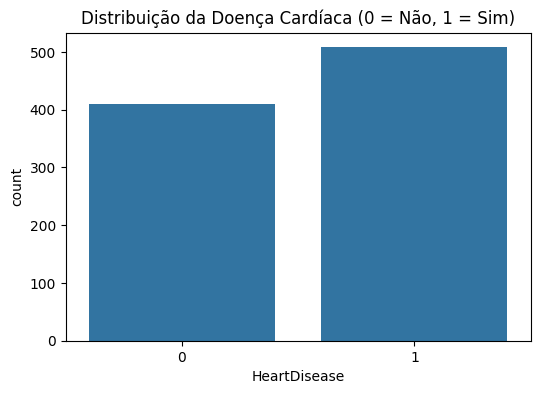

In [ ]:
print("\n--- Distribuição da Variável Alvo ---")
print(df_eda['HeartDisease'].value_counts(normalize=True) * 100)
print()

plt.figure(figsize=(6, 4))
sns.countplot(data=df_eda, x='HeartDisease')
plt.title('Distribuição da Doença Cardíaca (0 = Não, 1 = Sim)')
plt.show()

O cálculo da proporção da variável `HeartDisease` indica cerca de 55,3% de pacientes doentes (Classe 1) e 44,7% de saudáveis (Classe 0), comprovado pelo countplot acima. Por isso, a base de dados não apresenta desbalanceamento severo, o que permite utilizar as métricas padrão de avaliação sem a necessidade de técnicas de reamostragem.

## 3. Separação dos dados

Para garantir a confiabilidade da avaliação do modelo e prevenir o enviesamento de dados (*Data Leakage*), o conjunto de dados foi dividido antes da aplicação das transformações matemáticas. As seguintes diretrizes foram adotadas:

* **Proporção da Separação:** optou-se pela proporção de 80% para treinamento e 20% para teste. Como o dataset possui um tamanho moderado (**918 registros**), separar 20% garante um volume adequado de instâncias (cerca de **184 pacientes**) para validar o modelo de forma estatisticamente significante, deixando a maior fatia (80%, equivalente a **734 registros**) para o aprendizado dos algoritmos.
* **Estratificação:** foi utilizado o parâmetro `stratify` na variável-alvo (`HeartDisease`). Embora não haja um desbalanceamento severo, a estratificação assegura que a proporção exata de pacientes doentes (aproximadamente 55%) e saudáveis (aproximadamente 45%) seja mantida idêntica tanto no conjunto de treino quanto no de teste, evitando distorções na amostragem aleatória.
* **Reserva do Conjunto de Teste:** o conjunto de teste gerado nesta etapa (`X_test` e `y_test`) será trancado e mantido absolutamente intocado durante toda a fase de modelagem. Ele será acionado apenas na etapa final (Avaliação) para simular o desempenho do modelo escolhido em dados inéditos, não vistos nas etapas anteriores.

In [ ]:
from sklearn.model_selection import train_test_split

# Isolando as variáveis preditivas (X) e o alvo (y)
X = df_original.drop('HeartDisease', axis=1)
y = df_original['HeartDisease']

# Separação de Treino e Teste (80/20 com Estratificação)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Garante a mesma proporção de doentes/saudáveis nos conjuntos de treino e teste
)

print(f"Tamanho do Treino: {X_train.shape[0]} registros")
print(f"Tamanho do Teste: {X_test.shape[0]} registros")

Tamanho do Treino: 734 registros
Tamanho do Teste: 184 registros


A separação foi feita utilizando o dataset original da fonte (`df_original`), evidenciando que os dados de treino e teste não sofreram mudanças (por enquanto) com relação ao estado inicial dos dados. Apenas durante a etapa de pré-processamento (seção 5), será aplicada uma pipeline de processamento, transformando de maneira metódica os dados.

Os dados de treino compõem 734 registros, enquanto os de teste, 184 registros.

## 4. Análise exploratória

Nesta seção, será realizada a exploração visual e estatística do conjunto de dados para compreender o comportamento das variáveis preditivas numéricas e categóricas, detectar anomalias e avaliar as suas relações diretas com o atributo-alvo (`HeartDisease`).

### 4.1. Análise de Variáveis Numéricas
Utilização de boxplots para comparar variáveis contínuas (como idade e colesterol) com a variável alvo. Isso ajuda a identificar tendências, distribuições e a presença de valores atípicos (*outliers*).

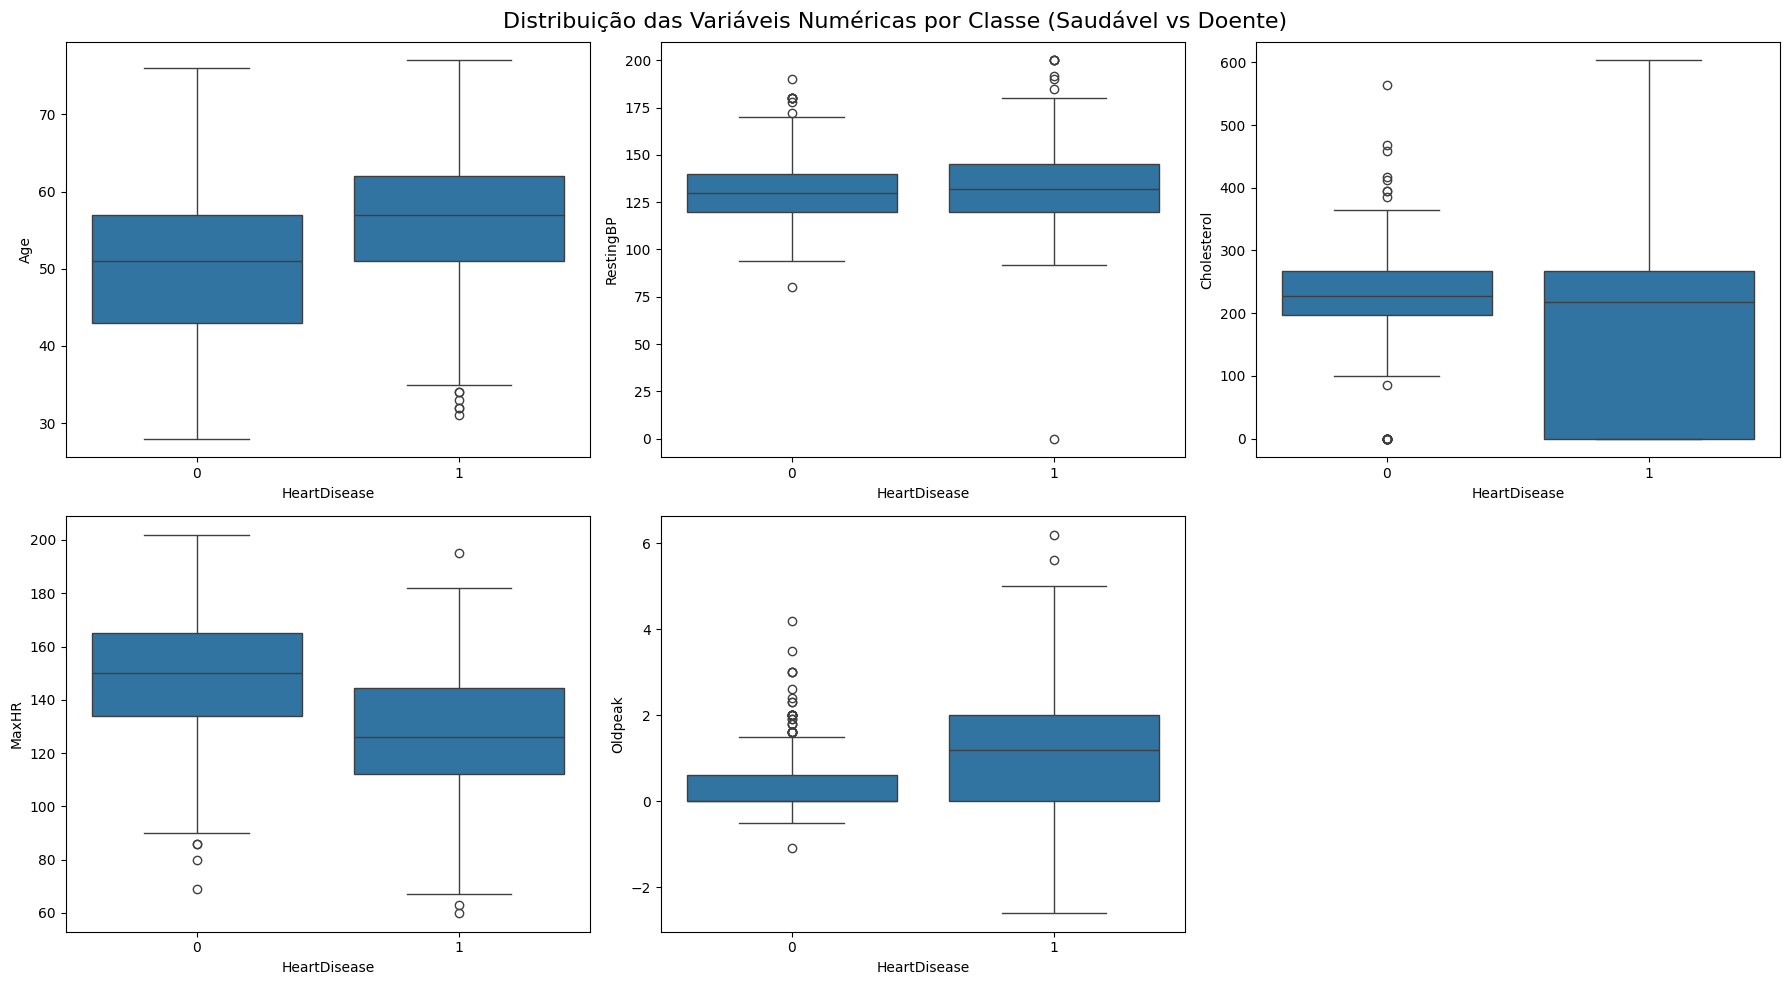

In [ ]:
colunas_numericas = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuição das Variáveis Numéricas por Classe (Saudável vs Doente)', fontsize=16)

axes = axes.flatten()
for i, col in enumerate(colunas_numericas):
    sns.boxplot(data=df_eda, x='HeartDisease', y=col, ax=axes[i])

# Removemos o 6º gráfico que ficaria vazio (temos 5 variáveis)
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

Pelos *boxplots* acima, é observado que:

- Os gráficos demonstram visualmente a presença de valores atípicos iguais a zero nas variáveis `Cholesterol` e `RestingBP`. Como a ausência total de pressão ou colesterol é biologicamente impossível, isso evidencia erros de registro que deverão ser tratados na etapa de pré-processamento.
- Os pacientes com diagnóstico positivo (Classe 1) possuem, em média, uma idade (`Age`) mais avançada, atingem uma frequência cardíaca máxima (`MaxHR`) consideravelmente menor durante o esforço e apresentam níveis mais elevados de depressão de ST (`Oldpeak`) do que os pacientes saudáveis (Classe 0).
- Nota-se que o `Oldpeak` para pacientes saudáveis está muito concentrado no zero. Além disso, a pressão arterial (`RestingBP`), desconsiderando o outlier zerado, possui medianas muito semelhantes entre os dois grupos, indicando que ela, de forma isolada, não é o fator de separação mais forte.

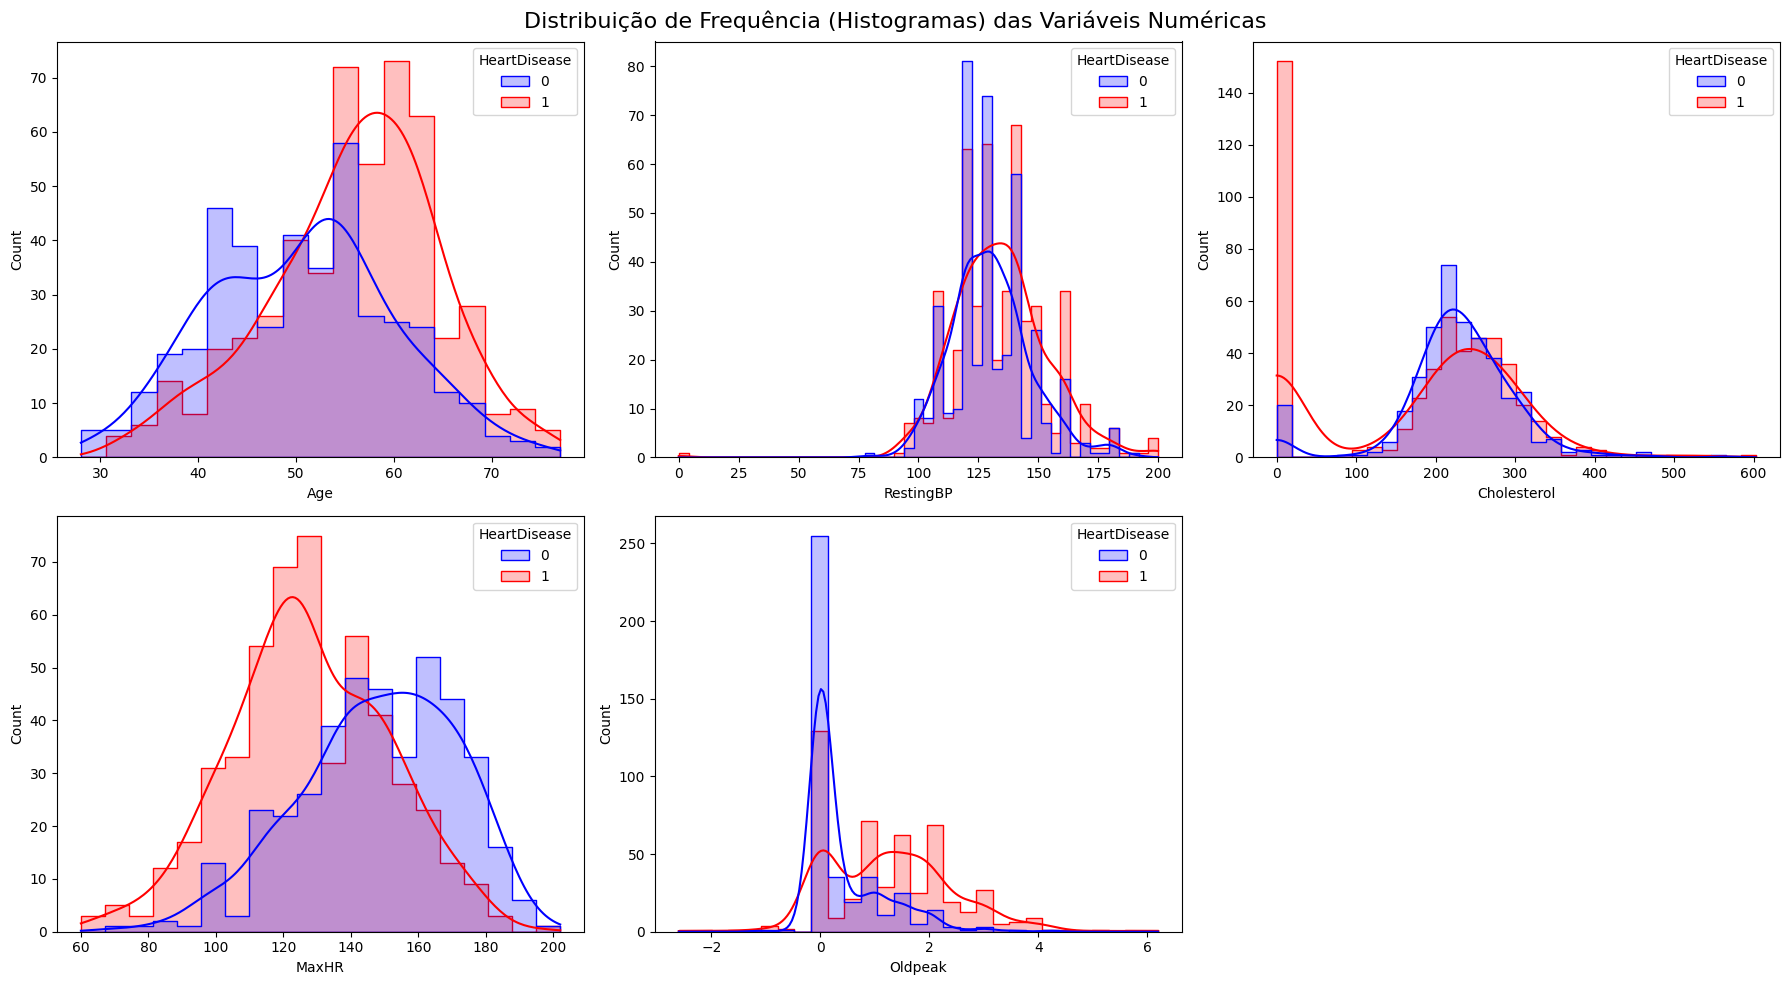

In [ ]:
# Configuração de cores (0 = Saudável/Azul, 1 = Doente/Vermelho)
cores_alvo = {0: "blue", 1: "red"}
colunas_numericas = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuição de Frequência (Histogramas) das Variáveis Numéricas', fontsize=16)

axes = axes.flatten()
for i, col in enumerate(colunas_numericas):
    # O histplot com kde=True mostra as barras e a linha de tendência
    sns.histplot(data=df_eda, x=col, hue='HeartDisease', kde=True, ax=axes[i], palette=cores_alvo, element="step")

# Removemos o 6º gráfico que ficaria vazio
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

Pelos histogramas acima, é possível ver que:

- Em `Age`, a curva de distribuição dos pacientes saudáveis (azul) aproxima-se de uma distribuição normal centralizada em idades mais jovens. Já a curva dos doentes (vermelha) tem um claro deslocamento (assimetria) para a direita, confirmando que o volume de diagnósticos positivos aumenta com a idade.
- Em `MaxHR`, ocorre o inverso da idade para a classe `HeartDisease = 1`. A curva de pacientes diagnosticados com a doença concentra sua grande massa à esquerda (frequências mais baixas), enquanto pacientes saudáveis atingem picos de frequência maiores.
- Em `Oldpeak`, nota-se um comportamento de sobreposição no valor zero (0), onde ambas as classes apresentam um pico. Isso ocorre porque a ausência de anomalia, nesse cenário, é o padrão para saudáveis, mas também pode ocorrer em pacientes com tipos específicos de doença cardíaca. A grande força preditiva desta variável, contudo, ocorre devido a sua assimetria à direita: a curva de pacientes saudáveis (azul) tende a zero após o valor inicial, enquanto a curva de doentes (vermelha) se prolonga significativamente, formando uma forte concentração de diagnósticos positivos entre os valores 1,0 e 4,0. Na prática, um `Oldpeak` elevado é um forte discriminador para a doença.
- O histograma do `Cholesterol` e do `RestingBP` exibe um pico anômalo e isolado exatamente no valor zero, reforçando a urgência da aplicação de uma técnica de imputação para não prejudicar a distribuição real dos dados válidos.

### 4.2. Análise de Variáveis Categóricas
Visualização da relação entre variáveis qualitativas (como sexo e tipo de dor no peito) e a incidência de doença cardíaca, permitindo identificar padrões comportamentais entre diferentes categorias.

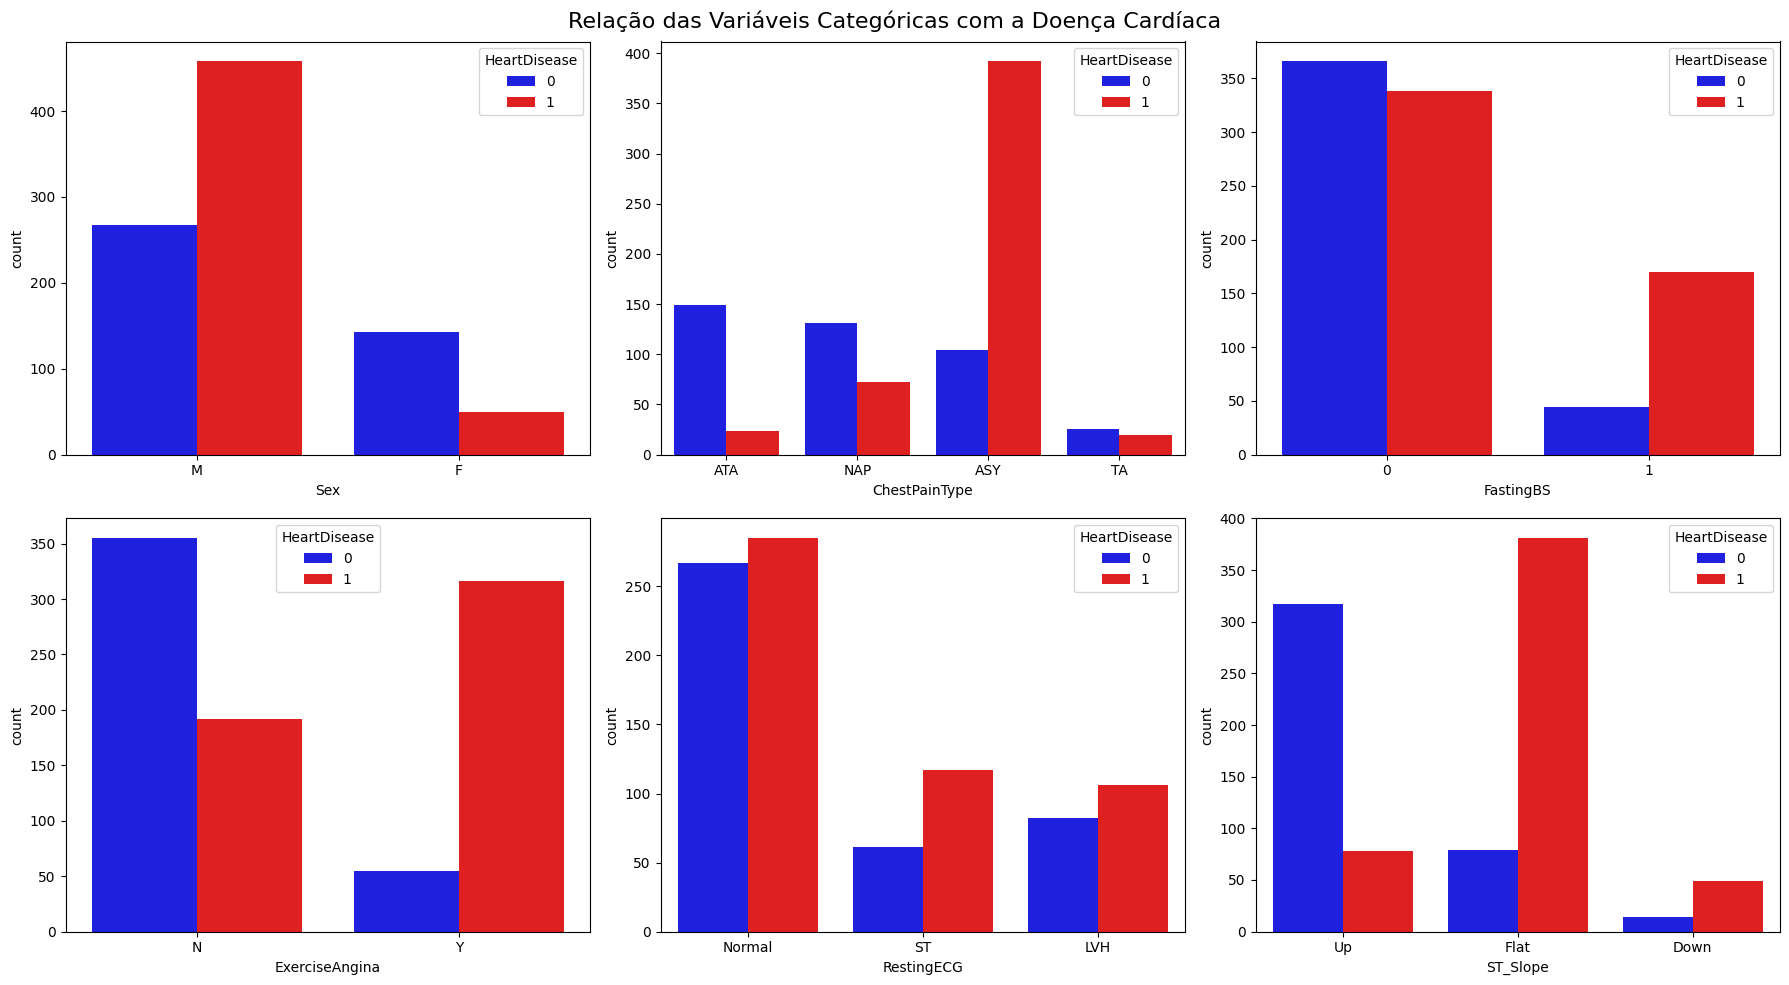

In [ ]:
colunas_categoricas = ['Sex', 'ChestPainType', 'FastingBS', 'ExerciseAngina', 'RestingECG', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Relação das Variáveis Categóricas com a Doença Cardíaca', fontsize=16)

axes = axes.flatten()
for i, col in enumerate(colunas_categoricas):
    sns.countplot(data=df_eda, x=col, hue='HeartDisease', ax=axes[i], palette=cores_alvo)

plt.tight_layout()
plt.show()

Pelos *countplots* acima, considerando a proporção entre pacientes saudáveis (azul) e doentes (vermelho) nas tabelas de frequência visualizadas, percebe-se que:

- **Sexo (`Sex`):** o gráfico revela uma disparidade significativa entre os gêneros. Enquanto o grupo feminino apresenta mais indivíduos saudáveis, o grupo masculino possui uma concentração massiva de diagnósticos positivos, indicando o sexo masculino como um forte fator de risco nesta base.
- **Tipo de Dor (`ChestPainType`):** a categoria 'ASY' (Assintomático) concentra a grande maioria dos casos positivos. Isso sugere que os pacientes doentes tendem a não apresentar os sintomas clássicos de dor no peito.
- **Glicemia em Jejum (`FastingBS`):** para pacientes com níveis normais (0), a proporção entre doentes e saudáveis é equilibrada. Contudo, entre os pacientes com glicemia elevada (1), o número de doentes é visivelmente superior.
- **Angina Induzida por Exercício (`ExerciseAngina`):** a resposta 'Y' (Sim) é composta quase que exclusivamente por pacientes doentes, sendo um indicativo crítico para a detecção de `HeartDisease`.
- **Eletrocardiograma em Repouso (`RestingECG`):** apresenta a distribuição mais branda entre as classes, indicando que, de forma isolada, não possui um poder de discriminação tão forte quanto as outras variáveis.
- **Inclinação ST (`ST_Slope`):** o formato da inclinação do segmento ST segmenta muito bem os pacientes. A inclinação 'Up' está fortemente associada a pacientes saudáveis, enquanto as inclinações 'Flat' (plana) e 'Down' (descendente) estão relacionadas aos diagnósticos positivos.

### 4.3. Matriz de Correlação Entre as Variáveis Numéricas e Variável Alvo

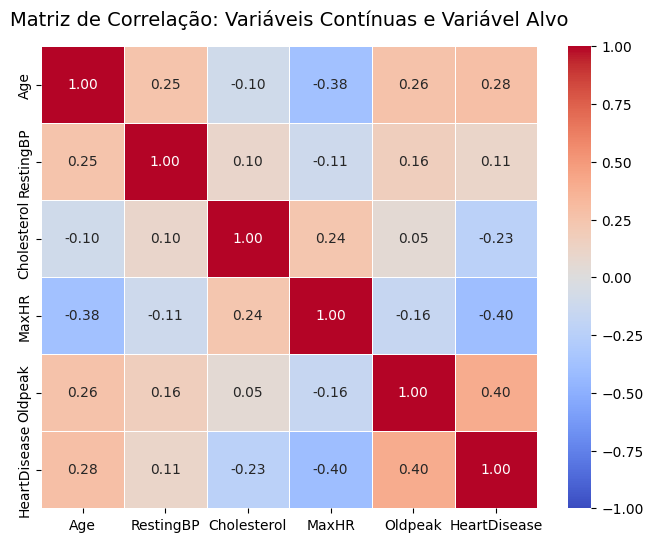

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lista com as variáveis contínuas E a variável alvo numerificada
colunas_para_correlacionar = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']

matriz_correlacao = df_eda[colunas_para_correlacionar].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao,
            annot=True,          # Mostra os números dentro dos quadrados
            fmt=".2f",           # Limita a 2 casas decimais
            cmap="coolwarm",     # Paleta ideal (azul para negativo, vermelho para positivo)
            vmin=-1, vmax=1,     # Força a escala a ir de -1 a 1
            linewidths=0.5)      # Adiciona uma linha sutil separando os blocos

plt.title("Matriz de Correlação: Variáveis Contínuas e Variável Alvo", fontsize=14, pad=15)
plt.show()

A matriz de correlação acima avalia a dependência linear entre as variáveis contínuas e a relação com a variável alvo (`HeartDisease`). Sendo assim, nota-se que:

* **Relação com o diagnóstico (Variável Alvo):**
  * As variáveis **Frequência Cardíaca Máxima (`MaxHR`)** e **Depressão de ST (`Oldpeak`)** apresentam as correlações mais expressivas com a doença cardíaca, com valores de **-0.40** e **0.40**, respectivamente. Isso indica que pacientes que atingem frequências cardíacas menores ou que apresentam valores elevados de depressão de ST possuem maior tendência ao diagnóstico positivo.
  * A Idade (`Age`) e o Colesterol (`Cholesterol`) também demonstram correlações lineares relevantes com o alvo (**0.28** e **-0.23**, respectivamente).

* **Relação biológica entre os exames:**
  * Entre as variáveis independentes, a correlação mais forte ocorre entre a Idade (`Age`) e a Frequência Cardíaca Máxima (`MaxHR`), com um valor de **-0.38**. Trata-se de uma correlação negativa moderada, comprovando o fato biológico de que a capacidade de atingir frequências cardíacas elevadas diminui gradativamente com o avanço da idade.
  * Observa-se também uma leve correlação positiva (**0.26**) entre a Idade (`Age`) e a Depressão de ST (`Oldpeak`), além de uma pequena correlação positiva (**0.25**) entre a `Age` e `RestingBP`.

* **Ausência de Multicolinearidade:**
  * Constata-se que não existem variáveis numéricas preditivas altamente correlacionadas entre si (nenhum valor se aproxima de 1 ou -1). Isso garante que os modelos de Aprendizado de Máquina não serão impactados por redundância de informações (multicolinearidade), o que torna todas as características numéricas relevantes para o treinamento do algoritmo.

## 5. Pré-processamento

Nesta etapa, os dados crus serão preparados para a modelagem. Com base na análise prévia (seção 2), não foram detectadas linhas duplicadas, dados nulos formais (`NaN`) ou desbalanceamento severo de classes que exigissem tratamento especial. Os tratamentos aplicados focaram nas seguintes anomalias e necessidades:

### 1. Inconsistências (Valores Zerados)
* **Problema encontrado:** nas seções 2 e 4, foi visto que as variáveis `Cholesterol` e `RestingBP` possuem registros com valor zero, o que representa uma impossibilidade biológica (erro de coleta).
* **Tratamento aplicado:** imputação estatística utilizando a mediana da respectiva coluna (`SimpleImputer` com `missing_values=0`).
* **Por que foi escolhido:** a remoção das linhas, especialmente no caso do colesterol, causaria uma perda excessiva de dados úteis. Optou-se pela mediana (e não pela média) por ser uma medida de tendência central altamente resistente a *outliers*.

### 2. Variáveis Categóricas
* **Problema encontrado:** alguns modelos de Machine Learning não conseguem processar atributos textuais (como "M" ou "ASY").
* **Tratamento aplicado:** transformação numérica binária utilizando o `OneHotEncoder`.
* **Por que foi escolhido:** permite que o modelo matemático interprete as categorias sem criar uma falsa relação de grandeza/ordem entre elas.

### 3. Escalonamento de Variáveis Numéricas
* **Problema encontrado:** os atributos contínuos possuem escalas muito diferentes (ex: `Age` varia em dezenas, enquanto `Cholesterol` varia em centenas). Isso pode enviesar o peso de certas variáveis no treinamento de determinados modelos de Aprendizado de Máquina.
* **Tratamento aplicado:** Padronização (*Standardization*) utilizando o `StandardScaler` da biblioteca Scikit-learn.
* **Por que foi escolhido:** ele centraliza os dados ao redor do zero e com variância unitária, garantindo que todas as variáveis tenham peso inicial idêntico durante o treinamento.

### Prevenção de Vazamento de Dados (*Data Leakage*)
Para garantir total isolamento das informações, todo este fluxo de pré-processamento foi encapsulado em um `ColumnTransformer` (Pipeline) da biblioteca Scikit-Learn. As regras estatísticas (como calcular a mediana) serão aprendidas **exclusivamente no conjunto de treinamento**. Posteriormente, essas regras fixas serão aplicadas de forma "cega" ao conjunto de teste, garantindo a integridade da avaliação.

In [ ]:
# Quantidade de registros com os atributos zerados em todo o dataset

print(f"Quantidade com (RestingBP = 0): {df_original[df_original['RestingBP'] == 0].value_counts().sum()}")
print(f"Quantidade com (Cholesterol = 0): {df_original[df_original['Cholesterol'] == 0].value_counts().sum()}")

Quantidade com (RestingBP = 0): 1
Quantidade com (Cholesterol = 0): 172


Pelo código acima, note a presença de apenas 1 registro com `RestingBP` inconsistente, porém 172 registros com `Cholesterol = 0`.

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

colunas_zeros_invalidos = ['RestingBP', 'Cholesterol']
colunas_numericas_normais = ['Age', 'FastingBS', 'MaxHR', 'Oldpeak']
colunas_categoricas = ['Sex', 'ChestPainType', 'ExerciseAngina', 'RestingECG', 'ST_Slope']

# Pipeline para colunas com anomalias (Imputa a mediana onde for 0, depois padroniza)
pipeline_zeros = make_pipeline(
    SimpleImputer(missing_values=0, strategy="median"),
    StandardScaler()
)

# Pipeline para colunas numéricas sem anomalias (padroniza a escala)
pipeline_normais = make_pipeline(
    StandardScaler()
)

pipeline_processamento = ColumnTransformer([
    ("limpeza_zeros", pipeline_zeros, colunas_zeros_invalidos),
    ("limpeza_normais", pipeline_normais, colunas_numericas_normais),
    ("limpeza_categorica", OneHotEncoder(drop='first', sparse_output=False), colunas_categoricas)
])

# Manter o resultado final no formato de tabela do Pandas
pipeline_processamento.set_output(transform="pandas")

print("Pipeline construída com sucesso!")

Pipeline construída com sucesso!


A pipeline para processamentos dos dados foi criada, eliminando os dados zerados e inconssitentes, aplicando o `StandardScaler` e aplicando o `OneHotEncoder` para a transformação de variáveis categóricas em um formato adequado para determinados algoritmos de Aprendizado de Máquina.

O `OneHotEncoder` foi configurado com o parâmetro `drop='first'`. Essa técnica remove a primeira categoria de cada variável codificada, já que o seu estado pode ser matematicamente deduzido pelas demais colunas restantes (por exemplo, se um paciente não é do sexo Masculino, assume-se logicamente que é do sexo Feminino, tornando a segunda coluna redundante).

In [ ]:
# O fit_transform aprende as regras estatísticas somente no X_train e já o transforma
X_train_preparado = pipeline_processamento.fit_transform(X_train)

# O transform aplica as regras aprendidas no X_test
X_test_preparado = pipeline_processamento.transform(X_test)

print("Pré-processamento aplicado com sucesso!\n")
print(f"Os atributos de treinamento passaram de {X_train.shape[1]} para {X_train_preparado.shape[1]} colunas.")

Pré-processamento aplicado com sucesso!

Os atributos de treinamento passaram de 11 para 15 colunas.


Com a aplicação dos pipelines de processamento no bloco de código acima, houve um aumento na quantidade de colunas por causa do `OneHotEncoder` utilizado. Nesse cenário, o codificador transforma as variáveis categóricas textuais em novas colunas numéricas binárias (contendo apenas 0 ou 1).

In [ ]:
X_train_preparado.head()

,limpeza_zeros__RestingBP,limpeza_zeros__Cholesterol,limpeza_normais__Age,limpeza_normais__FastingBS,limpeza_normais__MaxHR,limpeza_normais__Oldpeak,limpeza_categorica__Sex_M,limpeza_categorica__ChestPainType_ATA,limpeza_categorica__ChestPainType_NAP,limpeza_categorica__ChestPainType_TA,limpeza_categorica__ExerciseAngina_Y,limpeza_categorica__RestingECG_Normal,limpeza_categorica__RestingECG_ST,limpeza_categorica__ST_Slope_Flat,limpeza_categorica__ST_Slope_Up
485,0.339016,-0.517499,0.970012,1.835497,-0.324520,0.317046,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
486,-1.266031,-0.572835,0.122028,1.835497,1.689837,-0.440356,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
117,-0.159102,1.714383,0.546020,1.835497,-0.247045,0.601071,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
361,1.501291,-0.130147,-0.725956,-0.544812,-0.479470,-0.819056,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
296,0.671094,-0.130147,-0.407962,1.835497,0.101594,-0.156330,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


Visualização dos primeiros 5 registros presentes em `X_train_preparado`. Note que, realmente, há a presença de 15 colunas, e os valores que antes apresentavam diversas escalas (como `Age` e `RestingBP`) estão agora na mesma escala numérica.

## 6. Modelagem

Nesta etapa, realizamos o treinamento dos algoritmos de aprendizado de máquina utilizando o conjunto de treinamento processado (`X_train_preparado`). Para garantir uma comparação justa e evitar vazamento de dados, utilizamos a técnica de **Validação Cruzada (*Cross-Validation*) com 5 dobras (*folds*)**, avaliando o desempenho dos modelos em cinco "simulados" diferentes antes da prova final (com dados de teste).

Foi escolhido o valor de 5 partições (cv=5) pois, dado o tamanho do conjunto de treinamento (~587 registros), isso garante que cada fold de validação contenha aproximadamente 117 instâncias, um volume estatisticamente robusto para avaliar as métricas sem enfrentar alta variância.

**Modelos Utilizados e Parâmetros Principais:**
1. **Baseline (`DummyClassifier`):**
    - **Parâmetro:** `strategy="most_frequent"`.
    - Serve como o pior cenário aceitável. Este modelo não possui "inteligência", ele apenas prevê a classe que mais aparece (nesse cenário, a classe 1 - Doente). Qualquer modelo real deve superar o desempenho do Baseline.
2. **SGDClassifier (Gradiente Descendente Estocástico):**
    - **Parâmetros:** `max_iter=1000` (limite máximo de passadas nos dados para buscar a resposta matemática) e `random_state=42` (garantia de reprodutibilidade).
3. **RandomForestClassifier (Floresta Aleatória):**
    - **Parâmetros:** `n_estimators=100` (quantidade de árvores de decisão na floresta) e `random_state=42`.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Instanciando os modelos
baseline_clf = DummyClassifier(strategy="most_frequent")
sgd_clf = SGDClassifier(max_iter=1000, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Função de Validação Cruzada (extrai todas as métricas)
def avaliar_modelo(nome, modelo, X, y):
    y_pred_cv = cross_val_predict(modelo, X, y, cv=5)

    print(f"--- {nome} ---")
    print(f"Acurácia:  {accuracy_score(y, y_pred_cv)}")
    print(f"Precisão:  {precision_score(y, y_pred_cv, zero_division=0)}")
    print(f"Recall:    {recall_score(y, y_pred_cv)}")
    print(f"F1-Score:  {f1_score(y, y_pred_cv)}\n")

print("RESULTADOS DA VALIDAÇÃO CRUZADA:\n")
avaliar_modelo("Baseline (Dummy)", baseline_clf, X_train_preparado, y_train)
avaliar_modelo("SGD Classifier", sgd_clf, X_train_preparado, y_train)
avaliar_modelo("Random Forest Classifier", rf_clf, X_train_preparado, y_train)

RESULTADOS DA VALIDAÇÃO CRUZADA:

--- Baseline (Dummy) ---
Acurácia:  0.553133514986376
Precisão:  0.553133514986376
Recall:    1.0
F1-Score:  0.712280701754386

--- SGD Classifier ---
Acurácia:  0.840599455040872
Precisão:  0.8481927710843373
Recall:    0.8669950738916257
F1-Score:  0.8574908647990256

--- Random Forest Classifier ---
Acurácia:  0.8569482288828338
Precisão:  0.8508158508158508
Recall:    0.8990147783251231
F1-Score:  0.874251497005988



A avaliação exclusiva pela Acurácia pode ser enganosa em diagnósticos de saúde, por isso foram extraídas, além da acurácia, as métricas de Precisão, Recall e F1-Score através da previsão cruzada (`cross_val_predict`).

Analisando os resultados obtidos:
- O **Baseline** apresentou 100% de Recall apenas porque "chutou" que todos os pacientes estavam doentes, resultando em uma precisão baixíssima de 55%.
- O **SGDClassifier** obteve um desempenho sólido (84% de acurácia), com um Recall de 86,6%.
- O **Random Forest Classifier** superou o modelo SGDClassifier em todas as métricas, atingindo a maior Acurácia (85,6%) e, mais importante, o maior **Recall (89,9%)** e **F1-Score (87,4%)**.

No contexto clínico (diagnóstico de doenças cardíacas), a métrica de **Recall (Revocação)** é a mais crítica. Um Falso Negativo (classificar um paciente doente como saudável) tem um risco fatal, sendo muito mais prejudicial do que um Falso Positivo (que exigiria apenas mais exames preventivos). O Random Forest demonstrou a melhor capacidade de minimizar esses Falsos Negativos (beirando os 90% de taxa de acerto nos doentes).

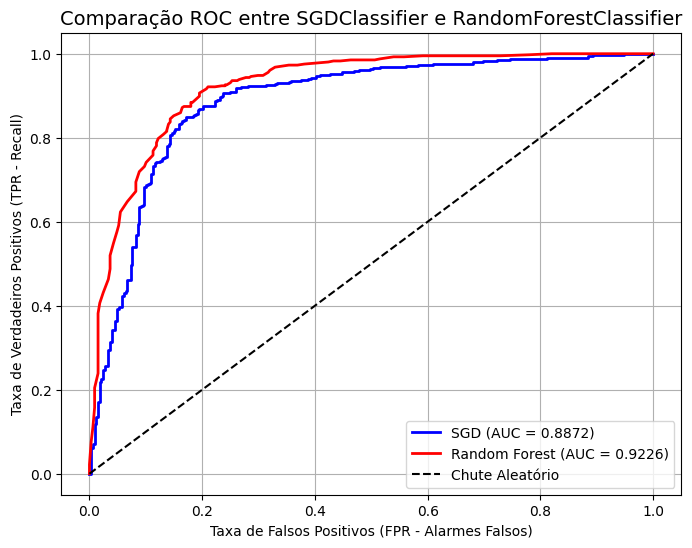

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Extraindo as pontuações do Random Forest (Probabilidades)
y_probas_rf = cross_val_predict(rf_clf, X_train_preparado, y_train, cv=5, method="predict_proba")
y_scores_rf = y_probas_rf[:, 1]

# Extraindo as pontuações do SGD (Função de Decisão)
y_scores_sgd = cross_val_predict(sgd_clf, X_train_preparado, y_train, cv=5, method="decision_function")

# Calculando as métricas para as duas Curvas ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_train, y_scores_rf)
fpr_sgd, tpr_sgd, thresholds_sgd = roc_curve(y_train, y_scores_sgd)

# Calculando o AUC de ambos os modelos
auc_rf = roc_auc_score(y_train, y_scores_rf)
auc_sgd = roc_auc_score(y_train, y_scores_sgd)

plt.figure(figsize=(8, 6))
plt.plot(fpr_sgd, tpr_sgd, "b-", linewidth=2, label=f"SGD (AUC = {auc_sgd:.4f})")
plt.plot(fpr_rf, tpr_rf, "r-", linewidth=2, label=f"Random Forest (AUC = {auc_rf:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Chute Aleatório")

plt.xlabel('Taxa de Falsos Positivos (FPR - Alarmes Falsos)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR - Recall)')
plt.title('Comparação ROC entre SGDClassifier e RandomForestClassifier', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

A análise comparativa através das Curvas ROC e da métrica AUC (*Area Under the Curve*) consolida de forma visual e matemática a escolha do modelo final para o projeto:

- A curva do `RandomForestClassifier` (linha sólida vermelha) exibe um arqueamento significativamente superior em direção ao canto superior esquerdo quando comparada ao `SGDClassifier` (linha sólida azul). Isso comprova que o `RandomForestClassifier` consegue maximizar a taxa de Verdadeiros Positivos (Recall) mantendo uma taxa de alarmes falsos mais controlada, em comparação com o `SGDClassifier`.
- O modelo linear SGD obteve um desempenho com um AUC de **0.8872**. Contudo, o *Random Forest* atingiu um patamar de ainda maior, registrando um AUC de **0,9226** (onde 1,0 seria o modelo perfeito).

BUSCA DO LIMIAR
Limiar Calculado pelo Sistema: 0.28
Recall Garantido no Treino:    0.9556650246305419
Taxa de Falsos Positivos:      0.3170731707317073



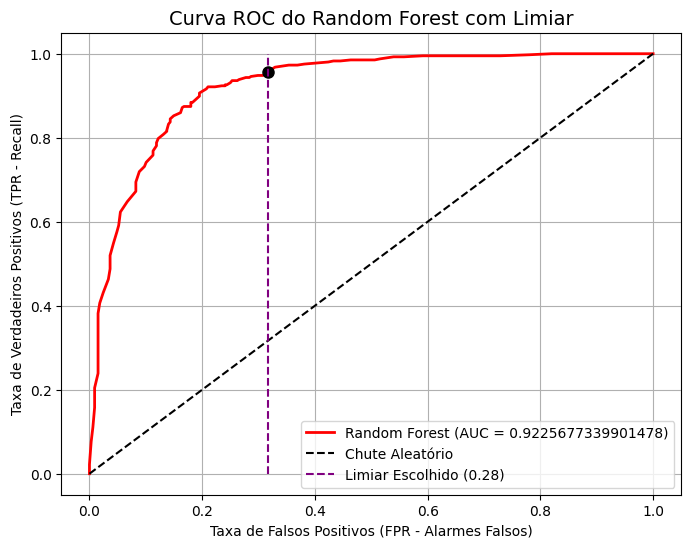

In [ ]:
# No mínimo 95% de Recall
meta_recall = 0.95

# Busca o primeiro índice onde o Recall bateu ou passou de 95%
indice_escolhido = np.where(tpr_rf >= meta_recall)[0][0]

limiar_clinico = thresholds_rf[indice_escolhido]
recall_atingido = tpr_rf[indice_escolhido]
fpr_gerado = fpr_rf[indice_escolhido]

print("BUSCA DO LIMIAR")
print(f"Limiar Calculado pelo Sistema: {limiar_clinico}")
print(f"Recall Garantido no Treino:    {recall_atingido}")
print(f"Taxa de Falsos Positivos:      {fpr_gerado}\n")

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, "r-", linewidth=2, label=f"Random Forest (AUC = {auc_rf})")
plt.plot([0, 1], [0, 1], 'k--', label="Chute Aleatório")

plt.plot(fpr_gerado, recall_atingido, "ko", markersize=8)
plt.vlines(x=fpr_gerado, ymin=0, ymax=1.0, colors='purple', linestyles='dashed', label=f'Limiar Escolhido ({limiar_clinico})')

plt.xlabel('Taxa de Falsos Positivos (FPR - Alarmes Falsos)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR - Recall)')
plt.title('Curva ROC do Random Forest com Limiar', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Decisão do Limiar (*Threshold*):**
matematicamente, o limiar é um número entre 0,0 e 1,0 que define a "linha de corte" para o diagnóstico. O padrão da biblioteca é 0,5 (50%). Contudo, por tratar-se de uma aplicação médica de alta criticidade, o foco principal é mitigar os Falsos Negativos. Como evidenciado pelas linhas tracejadas representando o limiar no gráfico ROC acima, foi identificado que o limiar ideal para atingir esta meta (*Recall* de 0,95) é de **0,28** (linha pontilhada roxa), garantindo o acolhimento preventivo de quase a totalidade dos pacientes doentes ao custo de um incremento aceitável de exames adicionais em pacientes saudáveis.

Portanto, por minimizar os falsos negativos, além do altíssimo poder de discriminação comprovado pelo AUC de 0.9333, o **Random Forest** será escolhido como o modelo final e definitivo para a avaliação no conjunto de testes, com o limiar ajustado metodicamente para a regra de negócio hospitalar.

In [ ]:
# Treinando o modelo selecionado com todos os dados de treino disponíveis
modelo_rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf_final.fit(X_train_preparado, y_train)

RandomForestClassifier(random_state=42)

Conforme o código acima, o **Random Forest** foi treinado com o *dataset* de treinamento, considerando um conjunto de 100 árvores (`n_estimators=100`).

## 7. Avaliação e Discussão

O modelo eleito como melhor foi o `RandomForestClassifier`. A sua escolha foi consolidada durante a validação cruzada (seção 6), onde superou o `SGDClassifier` tanto em métricas estáticas quanto na Curva ROC (alcançando um notável AUC de 0,92, aproximadamente). A arquitetura de árvores de decisão provou-se superior para mapear a complexidade das interações entre os sintomas fisiológicos.

Nesse sentido, nesta etapa final, o modelo `RandomForestClassifier` foi submetido ao teste definitivo utilizando o conjunto de teste (`X_test` e `y_test`), composto por instâncias mantidas em isolamento durante todo o projeto.

Para priorizar a segurança clínica, foi aplicado o limiar otimizado de **0,28** obtido metodicamente na seção anterior.

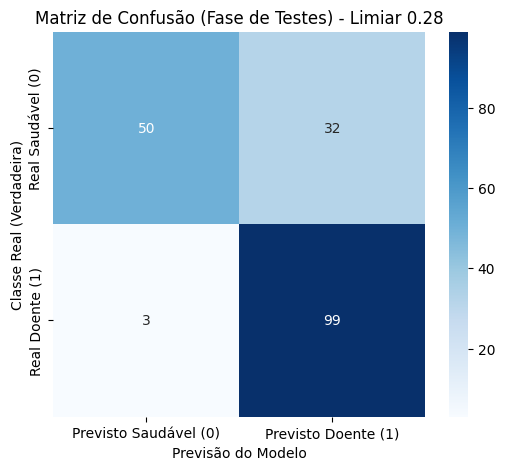

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

limiar_final = limiar_clinico
probabilidades_teste = modelo_rf_final.predict_proba(X_test_preparado)[:, 1]
y_pred_teste = (probabilidades_teste >= limiar_final).astype(int)

# Gerando a Matriz de Confusão
matriz_final = confusion_matrix(y_test, y_pred_teste)

# Plotando a Matriz
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto Saudável (0)', 'Previsto Doente (1)'],
            yticklabels=['Real Saudável (0)', 'Real Doente (1)'])
plt.title(f'Matriz de Confusão (Fase de Testes) - Limiar {limiar_final}', fontsize=12)
plt.ylabel('Classe Real (Verdadeira)')
plt.xlabel('Previsão do Modelo')
plt.show()

In [ ]:
print("--- MÉTRICAS FINAIS NO CONJUNTO DE TESTE ---")
print(f"Acurácia:  {accuracy_score(y_test, y_pred_teste)}")
print(f"Precisão:  {precision_score(y_test, y_pred_teste)}")
print(f"Recall:    {recall_score(y_test, y_pred_teste)}")
print(f"F1-Score:  {f1_score(y_test, y_pred_teste)}")

--- MÉTRICAS FINAIS NO CONJUNTO DE TESTE ---
Acurácia:  0.8097826086956522
Precisão:  0.7557251908396947
Recall:    0.9705882352941176
F1-Score:  0.8497854077253219


A partir dos dados acima, podemos concluir:

- **Recall de 97,06%:** na prática, de um total de 102 pacientes realmente doentes no conjunto de teste, o modelo foi capaz de detectar e alertar **99** com sucesso.
- **Precisão de 75,57%:** de todos os 131 diagnósticos de doença emitidos pelo algoritmo, **99** estavam corretos e **32** foram alarmes falsos.
- **F1-Score de 84,98%:** esta média harmônica comprova que o classificador manteve um excelente equilíbrio estrutural entre o Recall e a Precisão, mesmo após a agressiva redução do limiar de decisão.
- **Acurácia Geral de 80,98%:** considerando o cenário global (acertos em pacientes doentes somados aos acertos em pacientes saudáveis), o modelo realizou a predição correta para 149 dos 184 pacientes avaliados.


### Conclusões e Discussões Finais

#### **Quais erros foram observados:**
Pela análise da Matriz de Confusão:

- **Minimização do de Falsos Negativos:** foram registrados apenas **3 Falsos Negativos** (pacientes doentes classificados como saudáveis). Em um cenário médico real, este é o erro mais perigoso, pois atrasaria o tratamento de problemas cardíacos graves. Reduzir esse erro para apenas 3 ocorrências em um grupo de 102 doentes valida a altíssima utilidade clínica preventiva do sistema.
- **A questão dos Falsos Positivos:** como consequência matemática da redução do limiar (trade-off), o modelo gerou **32 Falsos Positivos** (pacientes saudáveis classificados como doentes). Embora isso reduza a Precisão geral, clinicamente esse impacto é perfeitamente aceitável: estes pacientes fariam exames complementares que descartariam a doença, garantindo que a segurança estivesse sempre em primeiro lugar.

#### **Quais limitações existem:**
  1. **Tamanho da Amostra:** o conjunto de dados possui pouco mais de 900 instâncias, o que é um volume relativamente pequeno para modelos de Aprendizado Profundo (*Deep Learning*), podendo impactar estes negativamente.
  2. **Escopo das Variáveis:** faltam dados críticos no dataset original que poderiam refinar o diagnóstico, como histórico familiar de doenças cardíacas, consumo de tabaco/álcool e Índice de Massa Corporal (IMC).

#### **O que poderia ser melhorado:**
  Para trabalhos futuros, o pipeline poderia ser enriquecido com as seguintes abordagens:
  1. **Otimização de Hiperparâmetros:** Utilizar algoritmos como `GridSearchCV` ou `RandomizedSearchCV` para encontrar a quantidade exata de árvores e profundidade máxima para o Random Forest, em vez de usar os valores padrão.
  2. **Aquisição de Dados:** Alimentar o algoritmo com um banco de dados de várias localidades e com maior quantidade de exames laboratoriais.


## Declaração de Uso de Inteligência Artificial
Foi utilizada a ferramenta de inteligência artificial Google Gemini para o desenvolvimento dos códigos envolvendo os gráficos boxplots e histogramas presentes na seção 4 do Jupyter Notebook (análise exploratória dos dados), como também na construção do código para a geração do gráfico da curva ROC, presente na seção 6. A atuação da ferramenta foi validada por todo o grupo por meio de uma revisão crítica conjunta do código-fonte, realizando ajustes e refinamentos considerados essenciais e/ou válidos pelos membros do grupo.